# 6. 银行客户分群与订阅行为分析

## 一、实验简介

本实验围绕 **UCI Bank Marketing Dataset（OpenML ID: 1461）** 展开，目标是基于银行电话营销活动中的客户属性与行为数据进行无监督分群（Customer Segmentation）。

在银行零售与财富管理场景中，客户分群常用于：

- 差异化营销策略（电话营销频次、渠道选择、产品推荐）
- 客户响应率预测与营销资源优化
- 客户运营与价值提升（留存、交叉销售、定期存款转化）

本实验重点关注三个问题：

1. 如何使用 **K-Means** 对银行客户进行自动分群？
2. 如何用 **肘部法（Elbow）** 与 **Silhouette 分数** 选择合理簇数 `k`？
3. 如何把"数学上的簇"转化为"业务可解释的人群画像"（如 `高余额保守型`、`年轻活跃订阅型`）？

## 二、实验目标

- 理解无监督学习与客户分群在银行场景中的应用价值。
- 掌握 K-Means 的训练流程与关键超参数（`n_clusters`、`n_init`、`random_state`）。
- 学会结合肘部法与 Silhouette 分数进行选 `k`。
- 学会输出聚类结果的业务画像，并给出针对性营销建议。

## 三、实验要求

- 使用 UCI Bank Marketing 数据集（通过 scikit-learn OpenML 接口获取）。
- 完成数据清洗、特征编码、特征标准化、K-Means 建模。
- 至少比较 `k=2~10` 的效果，输出肘部图与 Silhouette 曲线。
- 对最终簇做画像分析：规模、行为特征、业务命名与营销建议。

## 四、思考提示

1. 为什么聚类前通常需要做标准化？
2. 为什么不能只看肘部图，不看 Silhouette？
3. 聚类结果在不同随机种子下是否稳定？如何验证？


### 环境准备

导入本实验所需的全部第三方库。主要包括：

- `sklearn.cluster.KMeans` / `MiniBatchKMeans`：K-Means 聚类算法的标准实现与小批量加速版本
- `sklearn.datasets.fetch_openml`：从 OpenML 平台获取公开数据集
- `sklearn.preprocessing.OrdinalEncoder`：将分类特征编码为整数
- `sklearn.preprocessing.StandardScaler`：对特征做零均值单位方差标准化
- `sklearn.metrics.silhouette_score`：计算轮廓系数，评估聚类质量


In [76]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

RANDOM_STATE = 37  # 全局随机种子，保证实验可复现

# OpenML 1461 使用 V1~V16 + Class，需要映射回业务字段名。
OPENML_COL_MAP = {
	"V1": "age", "V2": "job", "V3": "marital", "V4": "education",
	"V5": "default", "V6": "balance", "V7": "housing", "V8": "loan",
	"V9": "contact", "V10": "day", "V11": "month", "V12": "duration",
	"V13": "campaign", "V14": "pdays", "V15": "previous", "V16": "poutcome",
	"Class": "y",
}


### 绘图风格配置

统一设置 Seaborn 主题与中文字体，使后续所有图表风格一致。


In [77]:
def configure_plot_fonts() -> None:
	"""配置绘图风格与中文字体。"""

	sns.set_theme(style="whitegrid")
	plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
	plt.rcParams["axes.unicode_minus"] = False


configure_plot_fonts()


## 1. 数据集介绍与读取

本实验使用 UCI Bank Marketing 数据集（OpenML ID: 1461），该数据集来源于葡萄牙银行的电话营销活动，目标是预测客户是否会订阅定期存款产品。

典型字段包括：

**客户属性特征：**
- `age`：客户年龄
- `job`：职业类型（管理、技术、服务等）
- `marital`：婚姻状况（已婚、单身、离异）
- `education`：教育程度（初等、中等、高等）
- `default`：是否有信用违约（是/否）
- `balance`：年均账户余额（欧元）
- `housing`：是否有住房贷款（是/否）
- `loan`：是否有个人贷款（是/否）

**营销活动特征：**
- `contact`：联系方式（手机、座机等）
- `day`：最后一次联系的日期（月中的天数）
- `month`：最后一次联系的月份
- `duration`：最后一次通话时长（秒）
- `campaign`：本次活动中联系该客户的次数
- `pdays`：距上次活动联系的天数（-1 表示从未联系）
- `previous`：本次活动前联系该客户的次数
- `poutcome`：上次营销活动的结果

**目标变量：**
- `y`：客户是否订阅了定期存款（yes/no）——本实验中不作为聚类特征，但用于事后画像分析

从业务角度看，这些变量覆盖了"人口属性、财务状况、营销互动历史"三个核心维度，非常适合做客户细分。

数据通过 scikit-learn 的 `fetch_openml` 接口获取，无需手动下载文件。OpenML 返回列名为 `V1~V16 + Class`，代码中会统一重命名为上述业务字段名（`age~poutcome + y`）。


In [78]:
# Ref: https://www.openml.org/d/1461
# Ref: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html

def load_bank_marketing_data() -> pd.DataFrame:
	"""通过 OpenML 获取 UCI Bank Marketing 数据集。"""

	dataset = fetch_openml(data_id=1461, as_frame=True, parser="auto")
	df = dataset.frame.rename(columns=OPENML_COL_MAP)
	print(f"数据集名称：{dataset.details['name']}")
	print(f"原始数据维度：{df.shape}")
	return df


df_raw = load_bank_marketing_data()
display(df_raw.head())


数据集名称：bank-marketing
原始数据维度：(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


## 2. 数据概览与质量检查

我们先检查数据类型、缺失值、重复样本，确保后续聚类质量。

这样做的原因是：

- 聚类完全依赖特征距离，脏数据会直接扭曲距离计算；
- 缺失值若不处理，会导致标准化与 K-Means 无法正常运行；
- 重复样本会放大某类客户的权重，影响簇中心位置；
- 在建模前先确认数据质量，能减少"调参但无效"的时间成本。


### 2.1 查看数据基本信息

使用 `df.info()` 输出每列的数据类型和非空数量，快速了解数据结构。


In [79]:
df = df_raw.copy()
display(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  int64   
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  category
dtypes: category(10), int64(7)
memory usage: 2.8 MB


None

### 2.2 检查缺失值

计算每列的缺失率（百分比），按从高到低排序，重点关注缺失率较高的列。


In [80]:
missing_ratio = (df.isna().mean() * 100).sort_values(ascending=False)
print("缺失率（前 10 列，单位 %）：")
print(missing_ratio.head(10).round(2))


缺失率（前 10 列，单位 %）：
age          0.0
job          0.0
marital      0.0
education    0.0
default      0.0
balance      0.0
housing      0.0
loan         0.0
contact      0.0
day          0.0
dtype: float64


### 2.3 检查重复样本

完全重复的行会在聚类中放大特定客户群的权重，需要了解其规模。


In [81]:
dup_count = df.duplicated().sum()
print(f"重复样本数：{dup_count}")


重复样本数：0


## 3. 数据预处理

处理步骤：

1. 分离目标变量 `y`（订阅结果），不参与聚类但用于后续画像分析
2. 对分类特征使用 `OrdinalEncoder` 进行编码
3. 对数值特征用中位数填补缺失值
4. 剔除常量列

为什么要这样处理：

- `y` 是标签信息，聚类是无监督任务，不应使用标签作为输入特征；
- K-Means 要求数值输入，分类变量需要编码（OrdinalEncoder 简单高效，适合教学演示）；
- 中位数对极端值更稳健，适合金融行为数据；
- 常量列没有区分度，保留只会增加计算量而不增加信息。

> **注意**：OrdinalEncoder 会为分类特征引入人为的有序关系，这在严格意义上并不理想。
> 更合理的方案包括 One-Hot 编码或仅使用数值特征。此处为教学简化处理，实际项目中应根据业务需求选择。


### 3.1 定义预处理函数

封装完整的预处理流程，便于复用和调试。函数接收原始 DataFrame，返回用于聚类的数值特征矩阵和分离出的目标变量。


In [82]:
TARGET_COL = "y"  # 列名已从 OpenML 的 "Class" 重命名为 "y"


def prepare_features_for_clustering(
	df_input: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.Series]:
	"""完成聚类前的数据清洗，返回 (数值特征矩阵, 目标变量)。"""

	df_work = df_input.copy()

	# 分离目标变量
	if TARGET_COL in df_work.columns:
		y_target = df_work[TARGET_COL].copy()
		df_work = df_work.drop(columns=[TARGET_COL])
	else:
		y_target = pd.Series(dtype="object")

	# 识别分类列与数值列
	cat_cols = df_work.select_dtypes(include=["category", "object"]).columns.tolist()
	num_cols = df_work.select_dtypes(include=[np.number]).columns.tolist()

	# 对分类列进行 OrdinalEncoder 编码
	if cat_cols:
		encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
		df_work[cat_cols] = encoder.fit_transform(df_work[cat_cols].astype(str))

	# 合并所有列为数值
	all_cols = num_cols + cat_cols
	df_num = df_work[all_cols].copy()

	# 缺失值填补：中位数
	df_num = df_num.fillna(df_num.median(numeric_only=True))

	# 剔除常量列
	non_constant_cols = [c for c in df_num.columns if df_num[c].nunique() > 1]
	df_num = df_num[non_constant_cols]

	return df_num, y_target


### 3.2 执行预处理并检查结果

调用上述函数，输出最终用于聚类的特征列表和目标变量分布。


In [83]:
X, y_target = prepare_features_for_clustering(df)
print("预处理后特征维度：", X.shape)
print("用于聚类的字段：")
print(X.columns.tolist())
print(f"\n目标变量 ({TARGET_COL}) 分布：")
print(y_target.value_counts())


预处理后特征维度： (45211, 16)
用于聚类的字段：
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

目标变量 (y) 分布：
y
1    39922
2     5289
Name: count, dtype: int64


### 3.3 异常值检测与剔除

K-Means 基于欧氏距离计算簇中心，对异常值（outliers）非常敏感——少量极端样本会显著拉偏簇中心位置，导致聚类结果失真。

本步骤使用 **IQR（四分位距）方法** 检测异常值：

$$
\text{IQR} = Q_3 - Q_1
$$

若某样本在**任意一个数值特征**上的取值超出 $[Q_1 - 1.5 \times \text{IQR},\ Q_3 + 1.5 \times \text{IQR}]$，则标记为异常。

> **注意**：仅对**连续数值特征**（如 `age`、`balance`、`duration` 等）计算 IQR。
> 经 OrdinalEncoder 编码的分类特征取值有限且离散，不适用 IQR 规则。


In [84]:
def detect_outliers_iqr(
	df_features: pd.DataFrame,
	continuous_cols: list[str],
	factor: float = 1.5,
) -> pd.Series:
	"""基于 IQR 规则标记异常样本。

	Parameters
	----------
	df_features : 特征矩阵（含连续列）
	continuous_cols : 用于检测异常的连续数值列名列表
	factor : IQR 倍数，默认 1.5（经典 Tukey 规则）

	Returns
	-------
	布尔 Series，True 表示该行为异常值。
	"""

	is_outlier = pd.Series(False, index=df_features.index)
	for col in continuous_cols:
		q1 = df_features[col].quantile(0.25)
		q3 = df_features[col].quantile(0.75)
		iqr = q3 - q1
		lower = q1 - factor * iqr
		upper = q3 + factor * iqr
		is_outlier = is_outlier | (df_features[col] < lower) | (df_features[col] > upper)
	return is_outlier


### 3.4 执行异常值剔除

识别原始数据中属于连续数值类型的列（排除经 OrdinalEncoder 编码的分类列），
运行 IQR 检测，输出被剔除的样本数量，并同步过滤 `X` 和 `y_target`。


In [85]:
# 识别原始连续数值列（编码前就是数值的列）
_original_num_cols = df.drop(columns=[TARGET_COL], errors="ignore") \
	.select_dtypes(include=[np.number]).columns.tolist()
# 仅保留在 X 中实际存在的列
continuous_cols = [c for c in _original_num_cols if c in X.columns]
print("用于异常值检测的连续特征：", continuous_cols)

outlier_mask = detect_outliers_iqr(X, continuous_cols)
n_outliers = outlier_mask.sum()
print(f"检测到异常样本数：{n_outliers}（占比 {n_outliers / len(X):.2%}）")

# 剔除异常样本
X = X.loc[~outlier_mask].reset_index(drop=True)
y_target = y_target.loc[~outlier_mask].reset_index(drop=True)
print(f"剔除后数据维度：{X.shape}")


用于异常值检测的连续特征： ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
检测到异常样本数：17018（占比 37.64%）
剔除后数据维度：(28193, 16)


## 4. 特征标准化

K-Means 使用欧氏距离，量纲差异会显著影响结果。标准化是必要步骤。

同时，训练/测试拆分时应只在训练集 `fit` 标准化器，再分别 `transform` 训练集与测试集，避免数据泄漏。


### 4.1 训练集 / 测试集拆分

按 80/20 比例拆分数据，同时保留对应的目标变量，用于后续画像分析。


In [86]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y_target, test_size=0.2, random_state=RANDOM_STATE,
)

print("训练集形状：", X_train.shape)
print("测试集形状：", X_test.shape)


训练集形状： (22554, 16)
测试集形状： (5639, 16)


### 4.2 StandardScaler 标准化

在训练集上拟合标准化器（学习均值和标准差），然后分别对训练集、测试集和全量数据进行转换。

$$
z = \frac{x - \mu}{\sigma}
$$

其中 $\mu$ 和 $\sigma$ 仅从训练集计算，这样可以避免**数据泄漏（data leakage）**。


In [87]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X)

print("训练集标准化后形状：", X_train_scaled.shape)
print("测试集标准化后形状：", X_test_scaled.shape)


训练集标准化后形状： (22554, 16)
测试集标准化后形状： (5639, 16)


## 5. 选择最优簇数 k（Elbow + Silhouette）

选 `k` 是 K-Means 的核心超参数决策，常用两种互补方法：

- **肘部法（Elbow Method）**：绘制不同 `k` 对应的 Inertia（簇内平方和），观察下降速度何时明显变缓（拐点）。
- **Silhouette 分数**：衡量每个样本与所在簇的紧密度 vs. 与最近邻簇的分离度，取值范围 $[-1, 1]$，越高越好。

当两者结论不一致时，需要结合**业务可解释性**做折中，而不是机械选最大分数。

> **加速说明**：由于 Bank Marketing 数据集样本量较大（约 45,000 条），对每个候选 `k` 都在全量训练集上计算 Silhouette 非常耗时。
> 本实验采用两项加速策略：
> 1. 使用 `MiniBatchKMeans` 替代 `KMeans`（小批量随机梯度更新簇中心，大幅减少每轮迭代时间）；
> 2. 在计算 Silhouette 时进行随机子采样（`silhouette_score(..., sample_size=8000)`），避免 $O(n^2)$ 的全量距离计算。


### 5.1 定义评估函数

下面定义两个辅助函数：
- `evaluate_k_candidates`：遍历 `k=2..10`，对每个 `k` 训练 MiniBatchKMeans 并记录 Inertia 与 Silhouette；
- `detect_elbow_k`：用"首末连线最大垂距法"自动定位肘点。


In [88]:
SILHOUETTE_SAMPLE_SIZE = 8000  # Silhouette 子采样大小，平衡精度与速度


def evaluate_k_candidates(
	X_scaled: np.ndarray,
	k_min: int = 2,
	k_max: int = 10,
	random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
	"""计算不同 k 的 Inertia 与 Silhouette 分数。

	使用 MiniBatchKMeans 加速训练，Silhouette 使用子采样加速计算。
	"""

	rows: list[dict[str, float | int]] = []
	n_samples = X_scaled.shape[0]
	sil_sample = min(SILHOUETTE_SAMPLE_SIZE, n_samples)

	for k in range(k_min, k_max + 1):
		km = MiniBatchKMeans(
			n_clusters=k,
			random_state=random_state,
			n_init=10,
			batch_size=1024,
		)
		labels = km.fit_predict(X_scaled)
		sil = silhouette_score(
			X_scaled, labels,
			sample_size=sil_sample,
			random_state=random_state,
		)
		rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil})
	return pd.DataFrame(rows)


def detect_elbow_k(k_values: np.ndarray, inertia_values: np.ndarray) -> int:
	"""用"首末点连线最大垂距"方法自动检测肘点。"""

	if len(k_values) < 3:
		raise ValueError("肘部法至少需要 3 个候选 k。")

	x = k_values.astype(float)
	y = inertia_values.astype(float)
	x1, y1 = x[0], y[0]
	x2, y2 = x[-1], y[-1]
	line_norm = float(np.hypot(y2 - y1, x2 - x1))
	if line_norm == 0:
		return int(k_values[0])

	distances: list[float] = []
	for xi, yi in zip(x, y):
		numerator = abs((y2 - y1) * xi - (x2 - x1) * yi + x2 * y1 - y2 * x1)
		distances.append(float(numerator / line_norm))

	distance_array = np.array(distances, dtype=float)
	distance_array[[0, -1]] = -1.0  # 端点不作为肘点
	return int(k_values[int(np.argmax(distance_array))])


### 5.2 运行评估并确定候选 k

对训练集运行上述函数，输出每个 `k` 的指标表格，并自动检测肘点与 Silhouette 最优 `k`。


In [89]:
k_eval_df = evaluate_k_candidates(X_train_scaled, k_min=2, k_max=10)
display(k_eval_df)

silhouette_k = int(k_eval_df.loc[k_eval_df["silhouette"].idxmax(), "k"])
elbow_k = detect_elbow_k(k_eval_df["k"].to_numpy(), k_eval_df["inertia"].to_numpy())

print(f"Silhouette 最优：k={silhouette_k}")
print(f"肘部法（最大垂距）检测：k={elbow_k}")


,k,inertia,silhouette
0,2,263011.330501,0.107442
1,3,250665.041092,0.083187
2,4,236294.081570,0.092090
3,5,223247.860925,0.080014
4,6,204137.545151,0.095150
5,7,196533.914969,0.095544
6,8,194086.146928,0.093114
7,9,185748.865909,0.093349
8,10,183479.295044,0.082475


Silhouette 最优：k=2
肘部法（最大垂距）检测：k=6


### 5.3 可视化：肘部图与 Silhouette 曲线

左图为肘部法（Inertia vs k），右图为 Silhouette 分数曲线。灰色虚线标注自动检测到的候选值。


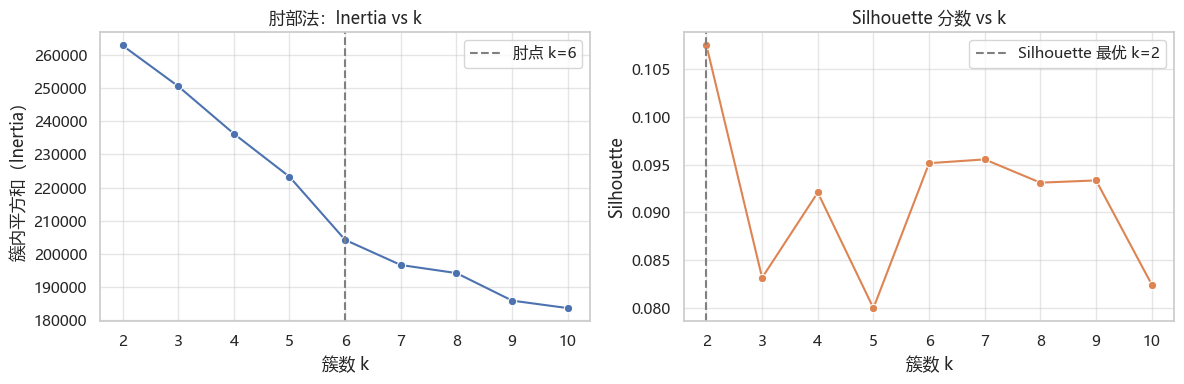

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=k_eval_df, x="k", y="inertia", marker="o", ax=axes[0], color="#4C72B0")
axes[0].axvline(elbow_k, linestyle="--", color="gray", label=f"肘点 k={elbow_k}")
axes[0].set_title("肘部法：Inertia vs k")
axes[0].set_xlabel("簇数 k")
axes[0].set_ylabel("簇内平方和（Inertia）")
axes[0].legend()

sns.lineplot(data=k_eval_df, x="k", y="silhouette", marker="o", ax=axes[1], color="#DD8452")
axes[1].axvline(silhouette_k, linestyle="--", color="gray", label=f"Silhouette 最优 k={silhouette_k}")
axes[1].set_title("Silhouette 分数 vs k")
axes[1].set_xlabel("簇数 k")
axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. 训练最终 K-Means 模型与多 k 测试集对比

在本节中，我们会先比较不同 `k` 在**测试集**上的聚类指标，再确定最终簇数。

评估指标含义：

- `Silhouette`：越高越好，表示簇内更紧凑、簇间更分离。

> 训练阶段同样使用 `MiniBatchKMeans` 加速，测试集 Silhouette 使用子采样。


### 6.1 定义测试集评估函数

在训练集上拟合模型，再用 `predict` 给测试集分配簇标签，计算测试集上的 Silhouette。


In [91]:
def evaluate_k_on_test(
	X_train_scaled: np.ndarray,
	X_test_scaled: np.ndarray,
	k_min: int = 2,
	k_max: int = 10,
	random_state: int = RANDOM_STATE,
) -> pd.DataFrame:
	"""在训练集拟合、在测试集上比较多 k 的 Silhouette。"""

	rows: list[dict[str, float | int]] = []
	n_test = X_test_scaled.shape[0]
	sil_sample = min(SILHOUETTE_SAMPLE_SIZE, n_test)

	for k in range(k_min, k_max + 1):
		km = MiniBatchKMeans(
			n_clusters=k,
			random_state=random_state,
			n_init=10,
			batch_size=1024,
		)
		km.fit(X_train_scaled)
		test_labels = km.predict(X_test_scaled)

		# 若测试集预测结果退化为单簇，则轮廓系数不可计算。
		if np.unique(test_labels).size < 2:
			sil = np.nan
		else:
			sil = silhouette_score(
				X_test_scaled, test_labels,
				sample_size=sil_sample,
				random_state=random_state,
			)

		rows.append({
			"k": k,
			"train_inertia": km.inertia_,
			"test_silhouette": sil,
		})

	result = pd.DataFrame(rows)
	result["rank_silhouette"] = result["test_silhouette"].rank(ascending=False, method="min")
	return result


### 6.2 运行测试集评估

输出每个 `k` 在测试集上的 Silhouette 分数及排名，确定最终的 `FINAL_K`。


In [92]:
k_test_eval_df = evaluate_k_on_test(X_train_scaled, X_test_scaled, k_min=2, k_max=10)
display(k_test_eval_df)

valid_k_df = k_test_eval_df.dropna(subset=["test_silhouette"])
score_best_k = int(valid_k_df.sort_values(["rank_silhouette", "k"]).iloc[0]["k"])
FINAL_K = score_best_k

print(f"肘部法建议（第5节）：k={elbow_k}")
print(f"测试集 Silhouette 最优：k={score_best_k}")
print(f"最终选定 FINAL_K = {FINAL_K}")


,k,train_inertia,test_silhouette,rank_silhouette
0,2,263011.330501,0.109815,1.0
1,3,250665.041092,0.081450,8.0
2,4,236294.081570,0.096876,3.0
3,5,223247.860925,0.081362,9.0
4,6,204137.545151,0.095896,4.0
5,7,196533.914969,0.097478,2.0
6,8,194086.146928,0.092910,6.0
7,9,185748.865909,0.094041,5.0
8,10,183479.295044,0.082085,7.0


肘部法建议（第5节）：k=6
测试集 Silhouette 最优：k=2
最终选定 FINAL_K = 2


### 6.3 可视化：测试集 Silhouette 曲线


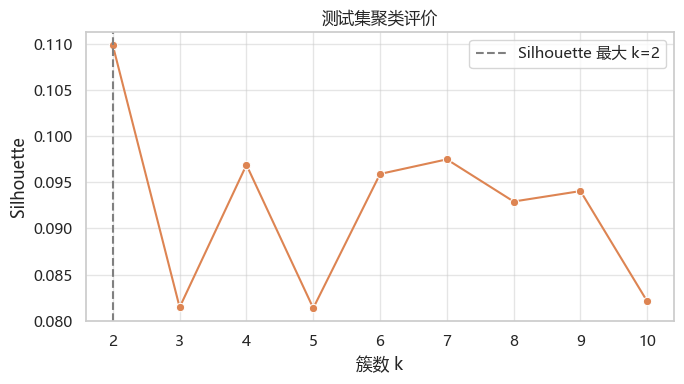

In [93]:
plt.figure(figsize=(7, 4))
sns.lineplot(data=k_test_eval_df, x="k", y="test_silhouette", marker="o", color="#DD8452")
plt.axvline(FINAL_K, linestyle="--", color="gray", label=f"Silhouette 最大 k={FINAL_K}")
plt.title("测试集聚类评价")
plt.xlabel("簇数 k")
plt.ylabel("Silhouette")
plt.legend()
plt.tight_layout()
plt.show()


### 6.4 训练最终模型并分配簇标签

使用标准 `KMeans`（而非 MiniBatchKMeans）训练最终模型，以获得更精确的簇中心。
对全量数据预测簇标签，构建包含特征与簇标签的结果表。


In [94]:
kmeans = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_train_scaled)

train_labels = kmeans.labels_
test_labels = kmeans.predict(X_test_scaled)
cluster_labels = kmeans.predict(X_all_scaled)

result_df = X.copy()
result_df["cluster"] = cluster_labels

sil_test = silhouette_score(X_test_scaled, test_labels)
print(f"测试集 Silhouette: {sil_test:.4f}（越高越好）")


测试集 Silhouette: 0.1105（越高越好）


## 7. 聚类结果可视化

使用 PCA 将高维特征压缩到二维，仅用于可视化观察簇结构。

> PCA 的降维仅是为了在二维平面上展示聚类结果，实际聚类仍然在原始高维空间中进行。


### 7.1 PCA 降维与散点图


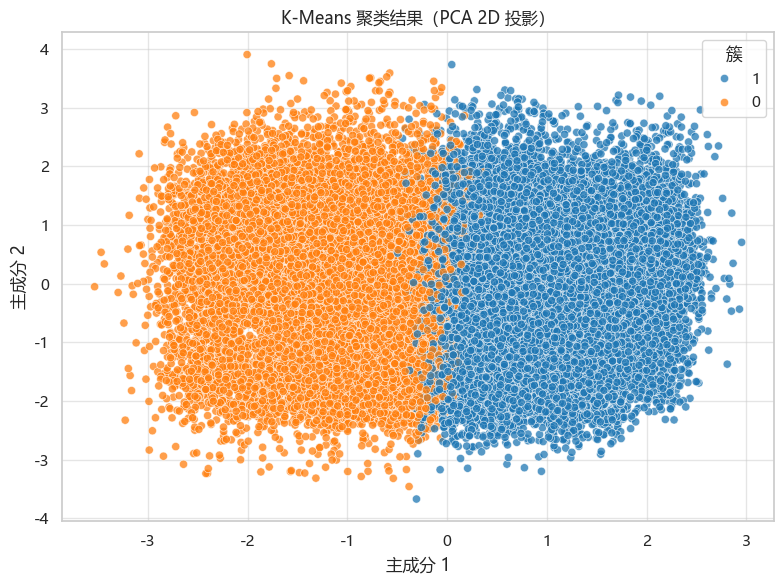

In [95]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_all_scaled)
plot_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
plot_df["cluster"] = cluster_labels.astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(
	data=plot_df,
	x="PC1",
	y="PC2",
	hue="cluster",
	palette="tab10",
	alpha=0.75,
	s=35,
)
plt.title("K-Means 聚类结果（PCA 2D 投影）")
plt.xlabel("主成分 1")
plt.ylabel("主成分 2")
plt.legend(title="簇")
plt.tight_layout()
plt.show()


### 7.2 各簇样本规模统计

输出每个簇的样本数量和占比，帮助判断是否存在严重不均衡。


In [96]:
cluster_size_df = (
	result_df["cluster"]
	.value_counts()
	.sort_index()
	.rename_axis("cluster")
	.reset_index(name="count")
)

print("各簇样本规模（文本摘要）：")
for _, row in cluster_size_df.iterrows():
	ratio = row["count"] / len(result_df)
	print(f"- cluster {int(row['cluster'])}: {int(row['count'])} 人，占比 {ratio:.2%}")


各簇样本规模（文本摘要）：
- cluster 0: 13240 人，占比 46.96%
- cluster 1: 14953 人，占比 53.04%


## 8. 客户画像：各簇银行客户特征

我们从两个角度做画像：

1. **原始量纲均值**：便于业务直觉解读
2. **标准化中心热力图**：便于横向比较"高于/低于总体"

此外，我们还将引入目标变量 `y`（是否订阅定期存款）的分布，帮助理解各簇的营销响应差异。


### 8.1 定义画像函数

封装画像逻辑：计算每簇的样本数、特征均值、占比，并可选地附加订阅率。


In [97]:
def profile_clusters(
	result_df: pd.DataFrame,
	feature_cols: list[str],
	y_target: pd.Series | None = None,
) -> pd.DataFrame:
	"""输出每个簇在原始量纲下的均值和样本占比，可选附加订阅率。"""

	size = result_df.groupby("cluster").size().rename("样本数")
	means = result_df.groupby("cluster")[feature_cols].mean()
	profile = size.to_frame().join(means, how="left")
	profile["占比"] = profile["样本数"] / profile["样本数"].sum()

	if y_target is not None:
		# 将目标变量转为字符串后映射为 0/1（兼容 categorical dtype）
		y_str = y_target.astype(str)
		y_binary = y_str.map({"1": 0, "2": 1, "no": 0, "yes": 1}).astype(float)
		sub_df = pd.DataFrame({"cluster": result_df["cluster"].values, "subscribed": y_binary.values})
		sub_rate = sub_df.groupby("cluster")["subscribed"].mean().rename("订阅率")
		profile = profile.join(sub_rate, how="left")

	return profile


### 8.2 输出各簇画像表

查看每个簇在原始量纲下的特征均值，以及该簇的订阅率（如高于总体均值，说明该群体更容易转化）。


In [98]:
feature_cols = X.columns.tolist()
cluster_profile = profile_clusters(result_df, feature_cols, y_target)
display(cluster_profile)


,样本数,age,balance,day,duration,campaign,pdays,previous,job,marital,education,default,housing,loan,contact,month,poutcome,占比,订阅率
cluster,,,,,,,,,,,,,,,,,,,
0,13240,40.905891,639.156269,16.711934,207.073112,2.395317,-1.0,0.0,5.023792,1.189502,1.355740,0.019486,0.291541,0.177795,0.089350,3.358988,3.0,0.46962,0.085801
1,14953,39.902361,577.905972,14.945429,203.835284,2.007624,-1.0,0.0,3.670768,1.136762,1.060255,0.024744,0.787334,0.174279,1.387548,7.461513,3.0,0.53038,0.030964


### 8.3 簇中心热力图

将 K-Means 的簇中心（标准化空间下）可视化为热力图。

- **红色**表示该特征在该簇中高于总体均值
- **蓝色**表示低于总体均值

为避免热力图过于拥挤，仅展示方差最大的前 12 个特征。


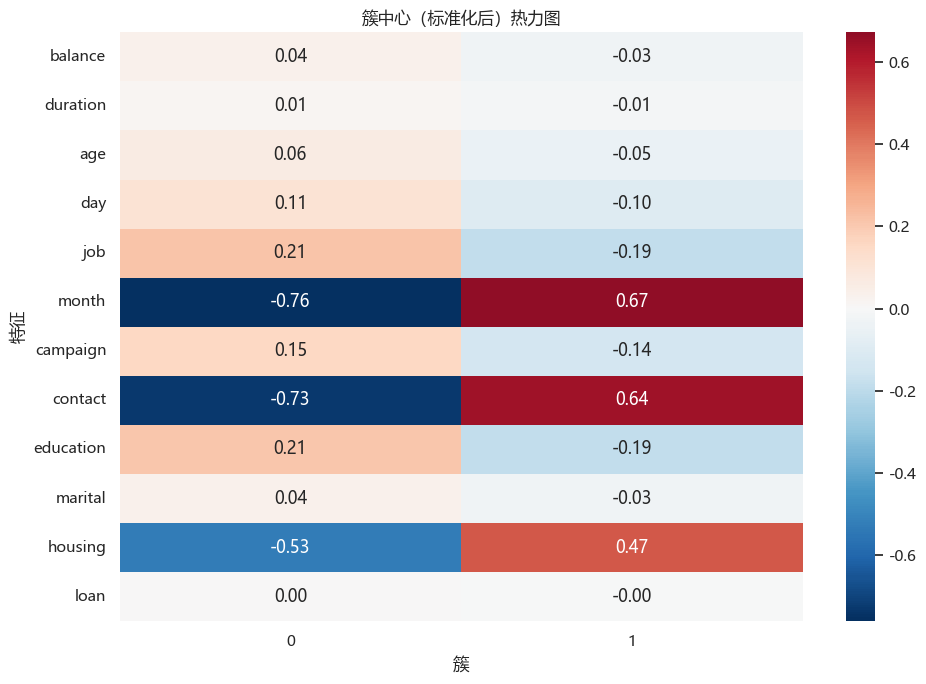

In [99]:
centers_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
centers_scaled.index.name = "cluster"

top_var_features = X.var().sort_values(ascending=False).head(12).index.tolist()
heatmap_df = centers_scaled[top_var_features].T

plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_df, cmap="RdBu_r", center=0, annot=True, fmt=".2f")
plt.title("簇中心（标准化后）热力图")
plt.xlabel("簇")
plt.ylabel("特征")
plt.tight_layout()
plt.show()


### 8.4 自动提取各簇高/低值特征

程序化地找出每个簇中标准化簇中心值最高和最低的 3 个特征，为人工画像提供数据支撑。


In [100]:
print("各簇画像解读（基于标准化簇中心的高低值）：")
for cluster_id in centers_scaled.index:
	row = centers_scaled.loc[cluster_id]
	high_features = row.sort_values(ascending=False).head(3).index.tolist()
	low_features = row.sort_values(ascending=True).head(3).index.tolist()
	print(f"- cluster {cluster_id}: 高值特征={high_features}；低值特征={low_features}")


各簇画像解读（基于标准化簇中心的高低值）：
- cluster 0: 高值特征=['job', 'education', 'campaign']；低值特征=['month', 'contact', 'housing']
- cluster 1: 高值特征=['month', 'contact', 'housing']；低值特征=['job', 'education', 'campaign']


## 9. 各簇人群自然语言画像

请结合你的运行结果，为每个簇撰写类似的画像描述。


## 10. 稳定性检查（可选）

K-Means 对初始化敏感。做稳定性检查的原因是：

- 如果不同随机种子下结果波动很大，说明分群结构不稳；
- 不稳定的分群不适合直接用于营销资源分配；
- 通过比较多次结果，可以判断当前 `k` 是否可靠。

我们这里用不同随机种子重复训练，并观察 Silhouette 的波动。


### 10.1 定义稳定性检查函数

对同一 `k`，使用不同随机种子各训练一次，记录 Inertia 和 Silhouette。


In [101]:
def stability_check(X_scaled: np.ndarray, k: int, seeds: list[int]) -> pd.DataFrame:
	"""使用不同随机种子训练 K-Means，记录 Inertia 与 Silhouette。"""

	rows = []
	n_samples = X_scaled.shape[0]
	sil_sample = min(SILHOUETTE_SAMPLE_SIZE, n_samples)

	for seed in seeds:
		km = KMeans(n_clusters=k, random_state=seed, n_init=10)
		labels = km.fit_predict(X_scaled)
		rows.append({
			"seed": seed,
			"inertia": km.inertia_,
			"silhouette": silhouette_score(
				X_scaled, labels,
				sample_size=sil_sample,
				random_state=seed,
			),
		})
	return pd.DataFrame(rows)


### 10.2 运行稳定性检查

使用 5 个不同的随机种子，观察 Silhouette 的标准差。标准差越小，说明聚类结构越稳定。


In [102]:
stability_df = stability_check(X_train_scaled, k=FINAL_K, seeds=[1, 7, 21, 37, 77])
display(stability_df)
print("Silhouette 标准差：", round(stability_df["silhouette"].std(), 4))


,seed,inertia,silhouette
0,1,262863.653246,0.109075
1,7,262863.749534,0.110915
2,21,262863.775557,0.107774
3,37,262863.709590,0.107937
4,77,262863.802583,0.109962


Silhouette 标准差： 0.0013


## 11. 实验结论（撰写参考）

请结合你的运行结果完成总结：

1. **最优簇数是多少？依据是什么？**
   - 说明肘部图的拐点位置；
   - 说明 Silhouette 最高对应的 `k`；
   - 给出最终选用 `k` 及业务解释。

2. **各簇客户行为差异是什么？**
   - 哪些簇年龄偏大、余额较高？
   - 哪些簇营销响应率（订阅率）最高？
   - 哪些簇通话时长最长、上次活动转化成功？

3. **如何落地到营销/运营策略？**
   - 指出至少 2 条分群差异化策略，并说明预期效果指标。
   - 例如：对"高响应率"簇增加电话营销频次；对"低参与"簇减少资源投入或更换渠道。

### 教学结论（参考）

在客户细分任务中，**标准化 + K-Means + 画像解释** 是一个高性价比基线流程。通过将簇中心转译为业务标签，可以把"算法聚类结果"转化为"可执行的银行运营策略"。结合目标变量 `y`（订阅结果）的事后分析，还能评估各群体的营销响应差异，为精准营销提供数据支撑。


## 12. 课堂思考题

1. 如果改用 `MiniBatchKMeans`，在大样本下速度和效果会怎样变化？
2. 如果改用层次聚类或 GMM，得到的人群边界有何差异？
3. 本实验对分类特征使用了 OrdinalEncoder，如果改用 One-Hot 编码，聚类结果会有何不同？
4. `duration`（通话时长）在实际预测场景中是否应该纳入特征？为什么？
5. 如何在线上验证分群策略确实提升了业务指标（如订阅转化率、客户留存率）？

---

### 建议运行顺序

1. 依次运行到第 5 节，观察 `k` 选择结果。
2. 继续运行第 8~9 节，完成画像命名与营销建议。
3. 最后根据图表与表格撰写实验报告。
